## This lecture is about WORD REPRESENTATION

**Previously:** Text processing fundamentals (L2) · Parsing (L3)

**Outline:**
- Why words need numeric representations, and what an **ideal** representation looks like
- **Discrete / sparse:** integer encoding, character encoding, one-hot, WordNet
- **Frequency-based:** Bag-of-Words, TF-IDF, co-occurrence, PMI
- Context matters: polysemy, homonymy, metonymy, synonymy
- **Distributed (dense) embeddings:** word2vec (skip-gram, CBOW, negative sampling), GloVe, FastText
- Contextualized and other representations, visualization (t-SNE)
- Sentence and document representations, and libraries in Python

# Word Representation
**Machines understand numeric values**, not strings. Words like *"Adenocarcinoma"*, *"Benign"*, *"Positive"*, *"Negative"* must be turned into numbers (vectors) before a model can use them.

## Characteristics of an IDEAL word representation
| Characteristic | Idea | Example |
|---|---|---|
| **Semantic richness** | words with similar meanings have similar representations (nuances, connotations, multiple senses) | *king* and *queen* are close |
| **Syntactic awareness** | encode grammatical roles and behavior (agreement, object relations, case) | *run* (verb) "I run every morning" vs *run* (noun) "He went for a run" |
| **Dimensionality & sparsity** | compact and dense, not huge and sparse | 300 dims instead of 100k |
| **Robustness to noise** | small variations/errors (typos, slang) shouldn't break meaning | *color* / *colour*, *recieve* → *receive* |
| **Learnability** | learnable from data, unsupervised or semi-supervised, without heavy annotation | from "The cat sat on the mat." / "The dog slept on the rug." learn that *cat* ≈ *dog* |
| **Context sensitivity** | the same word gets different representations in different contexts (polysemy, homonymy) | *bank* (money) vs *bank* (river) |
| **Generalization** | works for unseen or rare words and combinations | |

We'll grade each representation against this checklist.

# Discrete representations
## 1. Integer encoding
Map each word in the vocabulary to a unique number: $\{d_i\}_{i=1}^{M}, d_i \in \mathbb{N}$
e.g. *"There is a nodule in the left lung."* → There: $d_1$, is: $d_2$, a: $d_3$, …

**Limitations:** does not capture any relationship between words; challenging to interpret.

| Characteristic | Satisfied? | Explanation |
|---|---|---|
| Semantic richness | No | cat=12 and dog=13 are not semantically closer than cat=12 and apple=103 |
| Syntactic awareness | No | integers are arbitrary labels; noun vs verb not encoded |
| Dimensionality & sparsity | Partial | very low-dimensional (1D), but numerical closeness means nothing |
| Robustness to noise | No | color vs colour map to unrelated integers |
| Learnability | No | models may infer fake **ordinal** relationships (dog > cat) |
| Context sensitivity | No | one integer per word regardless of context |
| Generalization | No | no structure to support inference about unseen words |

## 2. Character-level integer encoding
*"nodule"* → n: $d_1$, o: $d_2$, d: $d_3$, …

**Limitations:** words have variable lengths; sparsity; characters carry no meaning ([3,1,20] doesn't say *cat* is an animal) and don't encode POS. ✅ But a typo (cat → kat) changes only one character, and models can learn prefixes/suffixes and spell out unseen words (with lots of data).

In [2]:
import re
import numpy as np

sentence = "There is a nodule in the left lung."
tokens = re.findall(r"\w+", sentence)

# word-level integer encoding
vocab = {w: i for i, w in enumerate(dict.fromkeys(tokens))}
print('vocab   :', vocab)
print('encoded :', [vocab[w] for w in tokens])

# character-level integer encoding
chars = {c: i for i, c in enumerate(sorted(set('abcdefghijklmnopqrstuvwxyz')), start=1)}
for w in ['nodule', 'cat', 'kat']:
    print(f'{w:7}->', [chars[c] for c in w])

vocab   : {'There': 0, 'is': 1, 'a': 2, 'nodule': 3, 'in': 4, 'the': 5, 'left': 6, 'lung': 7}
encoded : [0, 1, 2, 3, 4, 5, 6, 7]
nodule -> [14, 15, 4, 21, 12, 5]
cat    -> [3, 1, 20]
kat    -> [11, 1, 20]


## 3. One-hot vectors
Vector of vocabulary size $|V|$, all zeros except a 1 at the word's index: $v_k = [0, …, 1, …, 0]$

**Limitations:**
- **Sparse** representation (vocab-size dimensions)
- Ignores context (surrounding words)
- Words are intentionally dissimilar: the **dot product of any two different word vectors is 0** (all orthogonal, cat is no closer to dog than to banana)
- Inflexible for new words because of the fixed length; any typo creates a completely unrelated vector
- Linear models struggle; neural nets can learn weights but need lots of data and parameters

In [3]:
vocab_list = sorted(set(w.lower() for w in tokens))
V = len(vocab_list)
one_hot = {w: np.eye(V, dtype=int)[i] for i, w in enumerate(vocab_list)}

for w in vocab_list:
    print(f'{w:7}', one_hot[w])
print('\ndot(nodule, lung) =', one_hot['nodule'] @ one_hot['lung'], ' <- every pair of different words is orthogonal')

a       [1 0 0 0 0 0 0 0]
in      [0 1 0 0 0 0 0 0]
is      [0 0 1 0 0 0 0 0]
left    [0 0 0 1 0 0 0 0]
lung    [0 0 0 0 1 0 0 0]
nodule  [0 0 0 0 0 1 0 0]
the     [0 0 0 0 0 0 1 0]
there   [0 0 0 0 0 0 0 1]

dot(nodule, lung) = 0  <- every pair of different words is orthogonal


## 4. WordNet: vectors from annotated discrete properties
Represent a word by hand-annotated properties: $v_{nodule} = [1, …]$ for (plural-noun), (verb), (synonym-1), …, (synonym-n).

**WordNet:** a large lexical database of English, developed under cognitive psychologist **George A. Miller** at **Princeton**, first released **1985**.
- **Synsets** (synonym sets): each represents a distinct concept, e.g. {car, auto, automobile, machine, motorcar}
- **Semantic relations** between synsets:
  - **Hypernym**: more general concept (*vehicle* is a hypernym of *car*)
  - **Hyponym**: more specific (*car* is a hyponym of *vehicle*)
  - **Meronym**: part of a whole (*wheel* is a meronym of *car*)
  - **Holonym**: the whole of a part (*car* is a holonym of *wheel*)
  - **Antonym**: opposite meaning
- Covers nouns, verbs, adjectives, adverbs; many synsets have **example sentences**.

**Limitation:** limited coverage of vocabulary (new words, slang, domain terms), and building it requires manual annotation.

In [4]:
# !pip install nltk
import nltk
nltk.download('wordnet', quiet=True)
from nltk.corpus import wordnet as wn

car = wn.synset('car.n.01')
print('synonyms  :', car.lemma_names())
print('definition:', car.definition())
print('hypernyms :', car.hypernyms())
print('hyponyms  :', car.hyponyms()[:5])
print('meronyms  :', car.part_meronyms()[:5])
print('holonyms of wheel:', wn.synset('wheel.n.01').part_holonyms())
print('antonym of good  :', wn.synset('good.a.01').lemmas()[0].antonyms())
print('path similarity car~bus:', car.path_similarity(wn.synset('bus.n.01')))

synonyms  : ['car', 'auto', 'automobile', 'machine', 'motorcar']
definition: a motor vehicle with four wheels; usually propelled by an internal combustion engine
hypernyms : [Synset('motor_vehicle.n.01')]
hyponyms  : [Synset('pace_car.n.01'), Synset('beach_wagon.n.01'), Synset('stanley_steamer.n.01'), Synset('jeep.n.01'), Synset('electric.n.01')]
meronyms  : [Synset('car_seat.n.01'), Synset('high_gear.n.01'), Synset('window.n.02'), Synset('tail_fin.n.02'), Synset('third_gear.n.01')]
holonyms of wheel: [Synset('wheeled_vehicle.n.01')]
antonym of good  : [Lemma('bad.a.01.bad')]
path similarity car~bus: 0.125


# Frequency-based representations
## 5. Bag-of-Words (BOW)
- Build an $n \times t$ **document-term matrix**: $n$ documents, $t$ unique terms.
- Each column is a term; cell $(i, j)$ = how many times term $j$ appears in document $i$.

**Limitations:** high-dimensional and sparse; biased toward frequent words; word order and grammar discarded; typos (*Machien*, *lerning*) create new dimensions. ✅ Works reasonably well with linear models (Naive Bayes, Logistic Regression).

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

docs = ["I like solving interesting problems.",
        "What is machine learning?",
        "I'm not sure.",
        "Machien lerning predicts eveyrthing."]

bow = CountVectorizer(lowercase=False)
X = bow.fit_transform(docs)
print(pd.DataFrame(X.toarray(), columns=bow.get_feature_names_out(), index=[1, 2, 3, 4]).to_string())

   Machien  What  eveyrthing  interesting  is  learning  lerning  like  machine  not  predicts  problems  solving  sure
1        0     0           0            1   0         0        0     1        0    0         0         1        1     0
2        0     1           0            0   1         1        0     0        1    0         0         0        0     0
3        0     0           0            0   0         0        0     0        0    1         0         0        0     1
4        1     0           1            0   0         0        1     0        0    0         1         0        0     0


## 6. TF-IDF (Term Frequency – Inverse Document Frequency)
$$TF(t, d) = \frac{\text{number of times term } t \text{ appears in document } d}{\text{total number of terms in } d}$$

$$IDF(t) = \log\left(\frac{\text{number of documents in the corpus}}{\text{number of documents containing } t}\right)$$

$$\text{TF-IDF} = TF \times IDF$$

- **TF**: how important the term is *inside* the document.
- **IDF**: terms in a small share of documents (e.g. technical jargon) get **higher** weight than terms common to all documents (a, the, and), which get IDF = 0.

### Worked example
- Doc 1: "Apple and banana are fruits."
- Doc 2: "I like to eat apple and banana."
- Doc 3: "Banana and orange juice are delicious."

1. **Preprocess:** tokenize, lowercase, remove punctuation (keep stop words here)
2. **Vocabulary:** apple, and, banana, are, fruits, i, like, to, eat, orange, juice, delicious
3. **TF:** Doc 1 has 5 terms → each 1/5 = 0.20; Doc 2 → 1/7 ≈ 0.14; Doc 3 → 1/6 ≈ 0.17
4. **IDF:** apple, are: log(3/2); and, banana: log(3/3) = 0; all others: log(3/1)
5. **TF-IDF** = TF × IDF
6. Each document becomes a vector over the vocabulary.

⚠ **Note on the slides' numbers:** they compute log(3/2) ≈ 0.176 with **log base 10** but log(3/1) ≈ 1.0986 with the **natural log**, so the vectors on slide 43 mix the two bases. The code below uses one base consistently (natural log) and also shows the slides' mixed values so you can match them.

**Limitations:** lack of context; still high-dimensional and sparse; captures **importance**, not meaning. ✅ A very strong baseline for classification and retrieval with linear models.

In [8]:
import math
from collections import Counter

docs = ["Apple and banana are fruits.",
        "I like to eat apple and banana.",
        "Banana and orange juice are delicious."]
tokenized = [re.findall(r"[a-z]+", d.lower()) for d in docs]                      # step 1
vocab = list(dict.fromkeys(w for d in tokenized for w in d))                        # step 2
vocab = ["apple", "and", "banana", "are", "fruits", "i", "like", "to", "eat", "orange", "juice", "delicious"]

N = len(docs)
df = {t: sum(t in d for d in tokenized) for t in vocab}
idf = {t: math.log(N / df[t]) for t in vocab}                                        # step 4 (natural log)

def tf(t, d): return d.count(t) / len(d)                                             # step 3
tfidf = [[tf(t, d) * idf[t] for t in vocab] for d in tokenized]                       # step 5

print(f"{'term':10}{'DF':>4}{'IDF':>8}")
for t in vocab: print(f'{t:10}{df[t]:>4}{idf[t]:>8.4f}')
print()
print(pd.DataFrame(tfidf, columns=vocab, index=['Doc 1', 'Doc 2', 'Doc 3']).round(4).to_string())

term        DF     IDF
apple        2  0.4055
and          3  0.0000
banana       3  0.0000
are          2  0.4055
fruits       1  1.0986
i            1  1.0986
like         1  1.0986
to           1  1.0986
eat          1  1.0986
orange       1  1.0986
juice        1  1.0986
delicious    1  1.0986

        apple  and  banana     are  fruits       i    like      to     eat  orange   juice  delicious
Doc 1  0.0811  0.0     0.0  0.0811  0.2197  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0000
Doc 2  0.0579  0.0     0.0  0.0000  0.0000  0.1569  0.1569  0.1569  0.1569  0.0000  0.0000     0.0000
Doc 3  0.0000  0.0     0.0  0.0676  0.0000  0.0000  0.0000  0.0000  0.0000  0.1831  0.1831     0.1831


In [9]:
# Reproduce the slide's numbers: TF rounded to 2 decimals, log10 for log(3/2), ln for log(3/1)
slide_idf = {t: (math.log10(N / df[t]) if df[t] == 2 else math.log(N / df[t])) for t in vocab}
for name, d in zip(['Doc 1', 'Doc 2', 'Doc 3'], tokenized):
    print(name, [round(round(tf(t, d), 2) * slide_idf[t], 4) for t in vocab])

Doc 1 [0.0352, 0.0, 0.0, 0.0352, 0.2197, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Doc 2 [0.0247, 0.0, 0.0, 0.0, 0.0, 0.1538, 0.1538, 0.1538, 0.1538, 0.0, 0.0, 0.0]
Doc 3 [0.0, 0.0, 0.0, 0.0299, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1868, 0.1868, 0.1868]


In [10]:
# scikit-learn's TfidfVectorizer (default: smoothed idf = ln((1+N)/(1+df)) + 1, then L2-normalized rows)
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = ['This is the first document.', 'This document is the second document.']
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
print(vectorizer.get_feature_names_out())
print(X.toarray().round(3))

['document' 'first' 'is' 'second' 'the' 'this']
[[0.409 0.575 0.409 0.    0.409 0.409]
 [0.668 0.    0.334 0.469 0.334 0.334]]


## 7. Co-occurrence vectors
- **Term-document matrix** (BoW): how often a word occurs in a document.
- **Word-word co-occurrence matrix**: how often two words occur together within a **context window**.

Example (Jurafsky): contexts like *"…a tablespoonful of **apricot** preserve or jam…"*, *"…well suited to programming on the digital **computer**…"*

| word \ context | aardvark | computer | data | pinch | result | sugar |
|---|---|---|---|---|---|---|
| apricot | 0 | 0 | 0 | 1 | 0 | 1 |
| pineapple | 0 | 0 | 0 | 1 | 0 | 1 |
| digital | 0 | 2 | 1 | 0 | 1 | 0 |
| information | 0 | 1 | 6 | 0 | 4 | 0 |

*apricot* and *pineapple* get identical rows → similar words have similar vectors.

**Limitations:** raw frequency is very skewed and not very discriminative (*the*, *of* co-occur with everything); suffers from sparsity.

In [11]:
def cooccurrence(sentences, window=2):
    """Symmetric word-word co-occurrence counts within +-window words."""
    counts = Counter()
    for s in sentences:
        w = s.lower().split()
        for i, target in enumerate(w):
            for j in range(max(0, i - window), min(len(w), i + window + 1)):
                if i != j:
                    counts[(target, w[j])] += 1
    return counts

sents = ["I like deep learning", "I like NLP", "I enjoy flying"]
C = cooccurrence(sents, window=1)
words = list(dict.fromkeys(w for s in sents for w in s.lower().split()))
M = pd.DataFrame([[C[(a, b)] for b in words] for a in words], index=words, columns=words)
print(M.to_string())

          i  like  deep  learning  nlp  enjoy  flying
i         0     2     0         0    0      1       0
like      2     0     1         0    1      0       0
deep      0     1     0         1    0      0       0
learning  0     0     1         0    0      0       0
nlp       0     1     0         0    0      0       0
enjoy     1     0     0         0    0      0       1
flying    0     0     0         0    0      1       0


## 8. Pointwise Mutual Information (PMI)
From information theory: quantifies the **association** between two events (two words): how often they occur together compared with what we'd expect if they were **independent**.

$$PMI(w, c) = \log_2 \frac{P(w, c)}{P(w)\,P(c)}$$

From a co-occurrence matrix with counts $f_{ij}$ ($W$ words, $C$ contexts):
$$P(i, j) = \frac{f_{ij}}{\sum_{i=1}^{W}\sum_{j=1}^{C} f_{ij}}, \quad P(i) = \frac{\sum_{j=1}^{C} f_{ij}}{\sum_{i}\sum_{j} f_{ij}}, \quad P(j) = \frac{\sum_{i=1}^{W} f_{ij}}{\sum_{i}\sum_{j} f_{ij}}$$

Using the table above (dropping *aardvark*, total = 19):

| P(w,c) | computer | data | pinch | result | sugar | **P(w)** |
|---|---|---|---|---|---|---|
| apricot | 0.0 | 0.0 | 0.05 | 0.0 | 0.05 | 0.11 |
| pineapple | 0.0 | 0.0 | 0.05 | 0.0 | 0.05 | 0.11 |
| digital | 0.11 | 0.05 | 0.0 | 0.05 | 0.0 | 0.21 |
| information | 0.05 | 0.32 | 0.0 | 0.21 | 0.0 | 0.58 |
| **P(c)** | 0.16 | 0.37 | 0.11 | 0.26 | 0.11 | |

PMI is $-\infty$ when two words never co-occur, so in practice we use **Positive PMI**: $PPMI = \max(PMI, 0)$. The code fills in the PMI table left blank on the slides.

**Limitation:** **biased towards infrequent events**: very rare words get very high PMI (fixes: add-k smoothing, or raise $P(c)$ to the power 0.75).

In [12]:
words_r = ['apricot', 'pineapple', 'digital', 'information']
ctx = ['computer', 'data', 'pinch', 'result', 'sugar']
F = np.array([[0, 0, 1, 0, 1],
              [0, 0, 1, 0, 1],
              [2, 1, 0, 1, 0],
              [1, 6, 0, 4, 0]], dtype=float)

P_wc = F / F.sum()
P_w = P_wc.sum(axis=1, keepdims=True)
P_c = P_wc.sum(axis=0, keepdims=True)
print('P(w,c):'); print(pd.DataFrame(P_wc, words_r, ctx).round(2).to_string())
print('\nP(w):', P_w.ravel().round(2), '  P(c):', P_c.ravel().round(2))

with np.errstate(divide='ignore'):
    pmi = np.log2(P_wc / (P_w * P_c))
print('\nPMI(w,c):'); print(pd.DataFrame(pmi, words_r, ctx).round(2).to_string())
print('\nPPMI(w,c):'); print(pd.DataFrame(np.maximum(pmi, 0), words_r, ctx).round(2).to_string())

P(w,c):
             computer  data  pinch  result  sugar
apricot          0.00  0.00   0.05    0.00   0.05
pineapple        0.00  0.00   0.05    0.00   0.05
digital          0.11  0.05   0.00    0.05   0.00
information      0.05  0.32   0.00    0.21   0.00

P(w): [0.11 0.11 0.21 0.58]   P(c): [0.16 0.37 0.11 0.26 0.11]

PMI(w,c):
             computer  data  pinch  result  sugar
apricot          -inf  -inf   2.25    -inf   2.25
pineapple        -inf  -inf   2.25    -inf   2.25
digital          1.66 -0.56   -inf   -0.07   -inf
information     -0.80  0.57   -inf    0.47   -inf

PPMI(w,c):
             computer  data  pinch  result  sugar
apricot          0.00  0.00   2.25    0.00   2.25
pineapple        0.00  0.00   2.25    0.00   2.25
digital          1.66  0.00   0.00    0.00   0.00
information      0.00  0.57   0.00    0.47   0.00


### Summary so far: grading against the IDEAL checklist
| | Integer | Char-level | One-hot | BOW | TF-IDF |
|---|---|---|---|---|---|
| Semantic richness | No | No | No | No | No |
| Syntactic awareness | No | No | No | No | No |
| Dense / low-dim | Partial | Partial | No | No | No |
| Robust to noise | No | Partial | No | No | No |
| Learnability (with simple models) | No | Partial | Partial | Yes | Yes |
| Context sensitivity | No | No | No | No | No |
| Generalization | No | Partial | No | Limited | Limited |

**Progression:** one-hot → want a **dense** representation · TF-IDF → take **context** into account · co-occurrence → **distribution-driven** (rather than raw frequency) · PMI → **continuous** values.

# Context matters
> *"You shall know a word by the company it keeps."* (J.R. Firth, 1957)

| Phenomenon | Definition | Clinical example |
|---|---|---|
| **Polysemy** | same word, multiple **related** meanings | "cold": the common cold (viral infection) vs the patient feels cold (temperature) |
| **Homonymy** | same word, multiple **unrelated** meanings | "lead": the metal (heavy-metal poisoning) vs the verb ("lead to complications") |
| **Metonymy** | a word substituted for something closely related | "bottle" in pediatrics = the whole activity of bottle feeding, incl. the milk/formula |
| **Synonymy** | different words, similar meanings | "myocardial infarction", "heart attack", "cardiac arrest": used interchangeably in casual talk, but distinct clinically (cardiac arrest = sudden loss of heart function) |

# Distributed Representation
## Distributional hypothesis
- **Zellig S. Harris (1954)**: words with similar distributional properties (occurring in similar contexts) tend to have similar meanings.
- **J.R. Firth (1957)**: "You shall know a word by the company it keeps."
- This led to **distributional semantic models** that represent words as numeric vectors learned from patterns in massive corpora, using **machine learning**.

## Word embedding
**Definition:** words represented as **dense, continuous vectors** in a multi-dimensional space.
An embedding (latent) space is a manifold where similar items are **closer** together, so semantically similar words have nearby vectors.

- **Bengio et al. 2003**, *"A Neural Probabilistic Language Model"*: learn word vectors jointly with a neural language model to tackle the **curse of dimensionality**.
- **Mikolov et al. 2013**, **word2vec** (Tomáš Mikolov): trained to predict the probability of a word being a **context word** for a given target.

# word2vec
### Language model framing
Given a context (a few words), predict the next word:
*"While I am teaching this lecture, you are ______"* → strong? welcome? sleeping? eating? **listening**?

With more context (*"… you are ______ notes."*) the best answer becomes **taking**.

The model maps context words $\langle C_1 \rangle … \langle C_n \rangle$ to a probability for every word in the vocabulary, $p_1 … p_M$ with $\sum_{i=1}^{M} p_i = 1$ (a softmax).

### Training data: slide a window over the corpus
*"wikipedia is a free online encyclopedia …"*: with window = 2, target **free** → contexts **is, a, online, encyclopedia**.

Training loop: process input → **prediction** (e.g. 0.01, 0.41, 0.23, 0.03…) → compare with the **ground truth** (one-hot) → **error** → **update parameters**.

### Skip-gram vs CBOW
- **Skip-gram**: given the **word**, predict the **context**.
- **CBOW (Continuous Bag-of-Words)**: given the **context**, predict the **word** (target), e.g. *wikipedia is a free **⟨?⟩** online encyclopedia*.

### Architecture (Lilian Weng)
One-hot input $x \in \mathbb{R}^{V}$ → **embedding matrix** $W$ ($V \times N$) → hidden layer $h = W^T x$ (= the row of $W$ for the input word, an $N$-dim vector) → **context matrix** $W'$ ($N \times V$) → softmax over $V$ words.
- The model is trained to predict **one context word given one target word**; the word vectors are learned **indirectly**, through this language-model task.
- After training, **rows of $W$ are the word embeddings**.

In [13]:
def skipgram_pairs(sentence, window=2):
    w = sentence.split()
    return [(w[i], w[j]) for i in range(len(w)) for j in range(max(0, i - window), min(len(w), i + window + 1)) if i != j]

for t, c in skipgram_pairs("wikipedia is a free online encyclopedia", window=2):
    if t == 'free': print(f'target={t:6} context={c}')

print('\nCBOW example: context', ['is', 'a', 'online', 'encyclopedia'], '-> target', 'free')

target=free   context=is
target=free   context=a
target=free   context=online
target=free   context=encyclopedia

CBOW example: context ['is', 'a', 'online', 'encyclopedia'] -> target free


### Negative sampling
The full softmax over the whole vocabulary is expensive. Reframe the task: **given input X, Y, predict whether they are neighbors (1) or not (0)**.
- Positive pairs come from the text; **negative** pairs are random words from the vocabulary paired with the target.

**Training process:**
1. Pre-process the training text to determine the vocabulary size (`vocab_size`).
2. Create two matrices: **Embedding** and **Context**, each `vocab_size × embedding_size`.
3. In each training step, take one **positive** example and its associated **negative** examples.
4. **Look up** their embeddings (input word in Embedding, output words in Context).
5. Take the **dot product** of the input embedding with each context embedding (e.g. 0.2, −1.11, 0.74).
6. **Sigmoid** maps them to (0, 1) (e.g. 0.55, 0.25, 0.68).
7. **Error** = target − sigmoid (targets 1, 0, 0 → errors 0.45, −0.25, −0.68).
8. Use the error to **adjust the embeddings**.

> **Word of wisdom:** word2vec doesn't learn "meaning" directly. It learns **distributional similarity**: words are similar if they occur in similar contexts.

In [14]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))
dots = np.array([0.2, -1.11, 0.74])
targets = np.array([1, 0, 0])           # 1 positive neighbor, 2 negative samples
print('sigmoid:', sigmoid(dots).round(2))
print('error  :', (targets - sigmoid(dots)).round(2))

sigmoid: [0.55 0.25 0.68]
error  : [ 0.45 -0.25 -0.68]


## Hyper-parameters vs parameters
| Parameters | Hyper-parameters |
|---|---|
| internal to the model | configuration external to the model |
| **learned** from data during training | **cannot** be learned directly from the data |
| define what the model learned; used for predictions | set **before** training to control learning |
| e.g. the embedding & context matrices | set by the practitioner, often tuned; e.g. window size, # negatives, embedding size |

### word2vec hyper-parameters: what counts as "context"?
**Window size**: how many words on each side of the target count as context.

| Window | Embedding bias | What it captures |
|---|---|---|
| Small (2–3) | Syntactic | POS, morphology, function |
| Medium (5) | Mixed | syntax + semantics |
| Large (8–15) | Semantic / topical | theme, domain, topic |

**Number of negative samples (k)**: how many "wrong" contexts are shown per positive example. Pulls real (word, context) pairs together and pushes random fake pairs apart.
- k = 2–5 → small corpora; k = 5–20 → large corpora (Google News used ~5–15)

| Negatives | Effect |
|---|---|
| Too few | noisy embeddings, weak discrimination |
| Moderate | best balance of speed and quality |
| Too many | slower training, marginal gains |

In [15]:
# Skip-gram with negative sampling (SGNS) from scratch in NumPy, on a tiny synthetic corpus
rng = np.random.default_rng(0)

templates = ["the {a} chased the {b}", "a {a} ate the food", "my {a} sleeps on the rug",
             "the {f} is sweet", "i ate a ripe {f}", "fresh {f} juice is tasty",
             "the {r} rules the kingdom", "the {r} wore a crown", "long live the {r}"]
animals, fruits, royals = ['cat', 'dog', 'mouse'], ['apple', 'banana', 'mango'], ['king', 'queen', 'prince']
corpus = []
for _ in range(300):
    t = rng.choice(templates)
    corpus.append(t.format(a=rng.choice(animals), b=rng.choice(animals), f=rng.choice(fruits), r=rng.choice(royals)))

words = sorted({w for s in corpus for w in s.split()})
idx = {w: i for i, w in enumerate(words)}
V, N, window, k, lr, epochs = len(words), 16, 2, 5, 0.05, 15

freq = Counter(w for s in corpus for w in s.split())
neg_dist = np.array([freq[w] ** 0.75 for w in words]); neg_dist /= neg_dist.sum()   # unigram^0.75

W_emb = rng.normal(0, 0.1, (V, N))     # Embedding matrix  (the word vectors we keep)
W_ctx = np.zeros((V, N))               # Context matrix

pairs = [(idx[t], idx[c]) for s in corpus for t, c in skipgram_pairs(s, window)]
for epoch in range(epochs):
    lr = 0.05 * (1 - epoch / epochs) + 0.001                 # linearly decaying learning rate
    rng.shuffle(pairs)
    loss = 0
    for t, c in pairs:
        negs = rng.choice(V, size=k, p=neg_dist)
        ctx_ids = np.concatenate([[c], negs])
        labels = np.array([1] + [0] * k)
        scores = sigmoid(W_ctx[ctx_ids] @ W_emb[t])          # dot product -> sigmoid
        err = labels - scores                                  # error
        loss -= np.log(scores[0] + 1e-9) + np.log(1 - scores[1:] + 1e-9).sum()
        grad_t = err @ W_ctx[ctx_ids]
        W_ctx[ctx_ids] += lr * np.outer(err, W_emb[t])         # update context vectors
        W_emb[t] += lr * grad_t                                # update target vector
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f'epoch {epoch:2d}  loss {loss / len(pairs):.3f}')

epoch  0  loss 2.838
epoch  5  loss 1.828
epoch 10  loss 1.761
epoch 14  loss 1.738


In [16]:
def most_similar(word, topn=4):
    E = W_emb / np.linalg.norm(W_emb, axis=1, keepdims=True)
    sims = E @ E[idx[word]]
    return [(words[i], round(float(sims[i]), 2)) for i in np.argsort(-sims) if words[i] != word][:topn]

for w in ['cat', 'banana', 'queen']:
    print(f'{w:7} ->', most_similar(w))

cat     -> [('dog', 0.99), ('mouse', 0.99), ('food', 0.78), ('rug', 0.7)]
banana  -> [('apple', 0.98), ('mango', 0.96), ('tasty', 0.53), ('ate', 0.49)]
queen   -> [('prince', 1.0), ('king', 0.99), ('kingdom', 0.84), ('long', 0.82)]


### Analogy
Directions in embedding space carry meaning: **king − man + woman ≈ queen** (the offset man→woman is roughly parallel to king→queen).

**Demos:** [CMU Word Embedding Demo](https://www.cs.cmu.edu/~dst/WordEmbeddingDemo/index.html) · [word2vec demo](https://remykarem.github.io/word2vec-demo/) · [Embedding Projector](https://projector.tensorflow.org/)

In [17]:
# Pretrained vectors with gensim (downloads ~70MB the first time)
# !pip install gensim
import gensim.downloader as api
wv = api.load("glove-wiki-gigaword-50")

print(wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3))   # analogy
print(wv.most_similar('nodule', topn=5))
print('similarity(cat, dog)   =', wv.similarity('cat', 'dog'))
print('similarity(cat, apple) =', wv.similarity('cat', 'apple'))

[==================================================] 100.0% 66.0/66.0MB downloaded
[('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.759214460849762)]
[('cyst', 0.7718039751052856), ('nodules', 0.7497672438621521), ('abscess', 0.7411726117134094), ('polyp', 0.6999896168708801), ('polymetallic', 0.6942633390426636)]
similarity(cat, dog)   = 0.92180055
similarity(cat, apple) = 0.44069228


In [18]:
! pip install gensim

# GloVe: Global Vectors for Word Representation
[Pennington et al., Stanford, 2014](https://nlp.stanford.edu/pubs/glove.pdf)
- Unsupervised; captures meaning by analyzing **co-occurrence patterns** in a large corpus.
- Combines **global statistics** (the whole-corpus co-occurrence matrix) with **local context** (windows).
- **Why "Global"?** The statistics are collected at a global level, unlike word2vec, which streams over local windows.

### Intuition: ratios of co-occurrence probabilities encode meaning
Compare *ice* and *steam* by asking how strongly each co-occurs with probe words $k$: "how likely is context word $k$ to appear near *ice*?"

| Probability and ratio | k = solid | k = gas | k = water | k = fashion |
|---|---|---|---|---|
| P(k \| ice) | 1.9 × 10⁻⁴ | 6.6 × 10⁻⁵ | 3.0 × 10⁻³ | 1.7 × 10⁻⁵ |
| P(k \| steam) | 2.2 × 10⁻⁵ | 7.8 × 10⁻⁴ | 2.2 × 10⁻³ | 1.8 × 10⁻⁵ |
| P(k\|ice) / P(k\|steam) | **8.9** (≫1) | **8.5 × 10⁻²** (≪1) | **1.36** (≈1) | **0.96** (≈1) |

- **solid ≫ 1**: ice is solid-like, steam is not → strong discrimination
- **gas ≪ 1**: steam is gaseous, ice is not
- **water ≈ 1**: relevant to both (shared ground)
- **fashion ≈ 1**: irrelevant to both → no signal. The raw probabilities alone can't tell you that; the **ratio** cancels it out.

### Derivation (in simple words, but mathematically)
**Goal:** find a function $F$ such that the ratio of conditional probabilities is represented by word vectors:
$$F(w_i, w_j, \tilde{w}_k) = \frac{P_{ik}}{P_{jk}}$$
($w_i, w_j$: words being compared; $\tilde{w}_k$: probe/context word)

1. Vector spaces are linear, so use the **difference** $w_i - w_j$; the output is a **scalar**, so use a dot product: $F\big((w_i - w_j)^T \tilde{w}_k\big) = \frac{P_{ik}}{P_{jk}}$
2. Require $F(a - b) = \frac{F(a)}{F(b)}$ (a **homomorphism**): $F\big(w_i^T\tilde{w}_k - w_j^T\tilde{w}_k\big) = \frac{F(w_i^T\tilde{w}_k)}{F(w_j^T\tilde{w}_k)}$
3. The solution is $F(x) = e^x$, so $e^{w_i^T\tilde{w}_k} = P_{ik} = \frac{X_{ik}}{X_i}$
   - $X_{ik}$: number of times word $i$ appears beside word $k$; $X_i = \sum_k X_{ik}$
4. Take logs: $w_i^T \tilde{w}_k = \log X_{ik} - \log X_i$; absorb $\log X_i$ into a bias $b_i$ (plus $\tilde{b}_k$ for symmetry):
$$w_i^T\tilde{w}_k + b_i + \tilde{b}_k = \log X_{ik}$$
5. **Weighted least-squares objective** over the vocabulary $V$:
$$J = \sum_{i,k=1}^{V} f(X_{ik})\,\big(w_i^T\tilde{w}_k + b_i + \tilde{b}_k - \log X_{ik}\big)^2$$

### Training steps
1. **Co-occurrence matrix**: cell $(i, j)$ = how often words $i$ and $j$ appear together within a context window.
2. **Weighting function** $f(X_{ij})$: emphasizes important co-occurrences and de-emphasizes rare/noisy ones and very frequent ones (paper: $f(x) = (x/x_{max})^{0.75}$ if $x < x_{max}$, else 1; $f(0) = 0$).
3. **Objective function**: minimize the weighted squared difference between dot products of word vectors and log co-occurrence counts.
4. **Optimization**: gradient-based (SGD / AdaGrad), starting from **random** vectors.
5. **Resulting embeddings**: typically a few hundred dimensions; the paper uses $w + \tilde{w}$ as the final vector.

In [19]:
# Mini GloVe in NumPy on the same synthetic corpus
rng = np.random.default_rng(1)
X = np.zeros((V, V))
for s in corpus:                                    # 1) co-occurrence matrix (1/distance weighting as in the paper)
    w = s.split()
    for i in range(len(w)):
        for j in range(max(0, i - window), min(len(w), i + window + 1)):
            if i != j: X[idx[w[i]], idx[w[j]]] += 1 / abs(i - j)

x_max, alpha = 20, 0.75
f = np.where(X < x_max, (X / x_max) ** alpha, 1.0) * (X > 0)   # 2) weighting function
logX = np.log(np.where(X > 0, X, 1))

Wg, Wc = rng.normal(0, 0.1, (V, N)), rng.normal(0, 0.1, (V, N))
bg, bc = np.zeros(V), np.zeros(V)
lr, eps = 0.1, 1e-8
hist = [np.zeros_like(a) for a in (Wg, Wc, bg, bc)]  # AdaGrad accumulators (as in the GloVe paper)
for epoch in range(600):                            # 3) objective + 4) optimization (full-batch AdaGrad)
    diff = Wg @ Wc.T + bg[:, None] + bc[None, :] - logX
    J = (f * diff ** 2).sum()
    g = 2 * f * diff
    grads = [g @ Wc, g.T @ Wg, g.sum(1), g.sum(0)]
    for p, gr, h in zip((Wg, Wc, bg, bc), grads, hist):
        h += gr ** 2
        p -= lr * gr / (np.sqrt(h) + eps)
    if epoch in (0, 50, 200, 599): print(f'epoch {epoch:4d}  J = {J:.2f}')

# J drops to ~0 because this toy corpus has fewer co-occurrence cells than parameters;
# on a real corpus the loss stays well above zero.
G = Wg + Wc                                         # 5) resulting embeddings
G = G / np.linalg.norm(G, axis=1, keepdims=True)
for w in ['dog', 'mango', 'king']:
    sims = G @ G[idx[w]]
    print(f'{w:6} ->', [(words[i], round(float(sims[i]), 2)) for i in np.argsort(-sims) if words[i] != w][:3])

epoch    0  J = 1099.03
epoch   50  J = 0.05
epoch  200  J = 0.00
epoch  599  J = 0.00
dog    -> [('mouse', 0.92), ('cat', 0.92), ('the', 0.88)]
mango  -> [('fresh', 0.87), ('ripe', 0.86), ('banana', 0.85)]
king   -> [('prince', 0.92), ('long', 0.92), ('live', 0.91)]


## Limitations of word2vec / GloVe
- **Context-agnostic**: the same vector for a word regardless of its context (*bank* of a river = *bank* account).
- **Out-of-vocabulary (OOV) words**: a word not seen in training has **no embedding** (e.g. trained on "Tensor", "Flow" but asked for "Tensorflow").
- **Morphology**: no parameter sharing between words with the same root (*eat* / *eaten*); each word is learned separately from its own contexts.

# FastText
[Bojanowski et al., Facebook AI Research (FAIR), 2016](https://arxiv.org/pdf/1607.04606.pdf)
- An **extension of word2vec** that improves vectors for **morphologically rich** languages.
- Learns embeddings for **character n-grams**; a word's vector is the sum (or average) of its n-gram vectors **plus** the word itself.
- Example: *"equal"*, n = 3, with boundary symbols `<` `>`: `<eq, equ, qua, ual, al>` and the whole word `<equal>`.
- ✅ Handles **OOV** words (build a vector from the n-grams) and shares parameters across *eat* / *eaten*.

In [20]:
def char_ngrams(word, n=3):
    w = f'<{word}>'
    return [w[i:i+n] for i in range(len(w) - n + 1)] + [w]

print(char_ngrams('equal'))
print('shared n-grams eat / eaten:', set(char_ngrams('eat')[:-1]) & set(char_ngrams('eaten')[:-1]))

# OOV: build a vector for an unseen word from n-gram vectors (random stand-ins here, learned in real fastText)
rng = np.random.default_rng(2)
ngram_vec = {}
def ft_vector(word):
    grams = char_ngrams(word)
    return np.mean([ngram_vec.setdefault(g, rng.normal(size=8)) for g in grams], axis=0)

for w in ['tensor', 'flow', 'tensorflow']: ft_vector(w)
cos = lambda a, b: float(a @ b / np.linalg.norm(a) / np.linalg.norm(b))
print('cos(tensorflow, tensor) =', round(cos(ft_vector('tensorflow'), ft_vector('tensor')), 2),
      '| cos(tensorflow, flow) =', round(cos(ft_vector('tensorflow'), ft_vector('flow')), 2))

['<eq', 'equ', 'qua', 'ual', 'al>', '<equal>']
shared n-grams eat / eaten: {'<ea', 'eat'}
cos(tensorflow, tensor) = 0.86 | cos(tensorflow, flow) = 0.73


### Remaining limitations of static embeddings (incl. FastText)
- **Context-agnostic**, **OOV** (word2vec/GloVe), **morphology** (word2vec/GloVe)
- **Dependency on training data**: quality depends heavily on the corpus. **Domain specificity**: general-corpus embeddings may perform poorly on specialized (e.g. clinical) text without domain-specific training or fine-tuning.
- **Dimensionality**: hundreds of dimensions, computationally expensive.
- **Interpretability**: dense vectors are hard to interpret compared to sparse ones like one-hot.

# Contextualized Representation
A word's use (syntax and semantics) **depends on its context**.

**Idea:** build a vector for each word **conditioned on its context**: the representation of each token is a **function of the entire input sentence**.
- Reading: **Peters et al., 2018**, *"Deep contextualized word representations"* (ELMo); later BERT and Transformers.

In [ ]:
# Contextual embeddings: the same word "bank" gets different vectors (needs: pip install transformers torch)
import torch
from transformers import AutoTokenizer, AutoModel

tok = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")

def word_vec(sentence, word):
    enc = tok(sentence, return_tensors="pt")
    
    with torch.no_grad():
        out = bert(**enc).last_hidden_state[0]
    return out[enc.input_ids[0].tolist().index(tok.convert_tokens_to_ids(word))]s
v1 = word_vec("I went to the bank to deposit money.", "bank")
v2 = word_vec("The boat reached the bank of the river.", "bank")
v3 = word_vec("She withdrew cash from the bank.", "bank")
cos = torch.nn.functional.cosine_similarity
print('money vs river :', cos(v1, v2, dim=0).item())
print('money vs cash  :', cos(v1, v3, dim=0).item())

/opt/homebrew/Caskroom/miniconda/base/envs/NLP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12925.34it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be i

money vs river : 0.5025616884231567
money vs cash  : 0.8679702877998352


# Other representations
| Type | Idea |
|---|---|
| **Multi-prototype** | several vectors per word, one per sense/usage, instead of a single embedding |
| **Multisource** | combine text with other sources for a more holistic meaning: knowledge bases (WordNet), lexical resources (dictionaries), visual (image/video), audio (sound, speech) |
| **Multilingual** | represent words from many languages in one unified space |
| **Task-specific** | tailor representations to the needs of a particular NLP task |
| **Time-specific** | capture how meaning and usage evolve over time |

# Visualization: t-SNE
**t-distributed Stochastic Neighbor Embedding**: dimensionality reduction for visualizing high-dimensional data in 2D or 3D ([live demo on MNIST](https://nicola17.github.io/tfjs-tsne-demo/)).

How it works:
1. **High-dimensional space**: start from the original vectors.
2. **Similarity measure**: compute pairwise similarities (Euclidean, cosine, …).
3. **Low-dimensional space**: create a 2D/3D space.
4. **Stochastic embedding**: place points so pairwise similarities are preserved as well as possible.
5. **Visualization**: plot them to reveal the relationships (clusters).

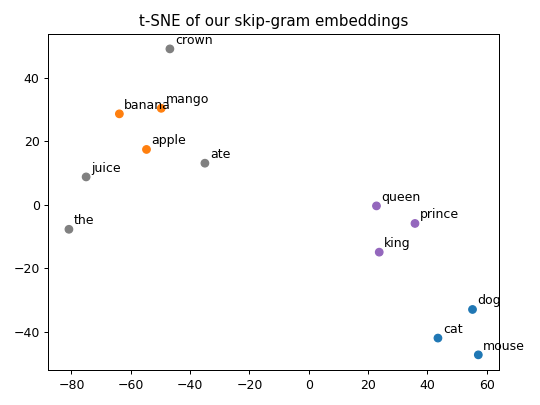

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

show = animals + fruits + royals + ['the', 'ate', 'juice', 'crown']
E = W_emb[[idx[w] for w in show]]
xy = TSNE(n_components=2, perplexity=4, random_state=0, init='pca').fit_transform(E)

colors = ['tab:blue'] * 3 + ['tab:orange'] * 3 + ['tab:purple'] * 3 + ['gray'] * 4
plt.figure(figsize=(6, 4.5))
plt.scatter(xy[:, 0], xy[:, 1], c=colors)
for (x, y), w in zip(xy, show):
    plt.annotate(w, (x, y), xytext=(4, 4), textcoords='offset points')
plt.title('t-SNE of our skip-gram embeddings')
plt.tight_layout(); plt.show()

# Sentence Representation
**Idea:** turn a sentence (a series of words) into one numerical vector that captures its meaning.

**Techniques:**
- **Bag-of-Words**: presence/frequency of words, ignoring grammar and order.
- **TF-IDF**: like BoW but weights words unique to a particular sentence/document.
- **Averaging word embeddings**: average the word2vec/GloVe vectors of all words in the sentence.
- **Neural networks**:
  - **RNNs**: process the sentence word by word, capturing sequential order.
  - **Transformers**: rich contextualized representations using the whole sentence.
  - **Dedicated sentence-embedding models**: Universal Sentence Encoder, **Sentence-BERT**.

# Document Representation
**Idea:** turn a whole document into a numerical format for analysis.

**Techniques:** BoW · TF-IDF (more weight to rare but significant words) · **Topic models (LDA, Latent Dirichlet Allocation)**: each document is a mixture of topics, each topic a distribution over words · **Doc2Vec**: like word2vec, a fixed-length dense vector per document · **Transformers** (e.g. BERT) with an aggregated representation.

In [ ]:
def sentence_vector(sentence):
    vecs = [W_emb[idx[w]] for w in sentence.lower().split() if w in idx]   # skip OOV words
    return np.mean(vecs, axis=0)

s1, s2, s3 = "the dog chased the cat", "a mouse ate the food", "i ate a ripe mango"
for a, b in [(s1, s2), (s1, s3)]:
    print(f'cos("{a}", "{b}") = {cos(sentence_vector(a), sentence_vector(b)):.2f}')

cos("the dog chased the cat", "a mouse ate the food") = 0.56
cos("the dog chased the cat", "i ate a ripe mango") = -0.37


In [ ]:
# Sentence-BERT  (pip install sentence-transformers)
from sentence_transformers import SentenceTransformer, util
sbert = SentenceTransformer("all-MiniLM-L6-v2")
emb = sbert.encode(["There is a nodule in the left lung.",
                    "A small mass was seen in the left lung.",
                    "The patient ate breakfast."])
print(util.cos_sim(emb, emb))

# Word Representation in Python
| Library | What for |
|---|---|
| **scikit-learn** | `CountVectorizer` (BoW), `TfidfVectorizer` (TF-IDF) — shown above |
| **Gensim** | train/load word2vec, FastText, Doc2Vec; `most_similar` |
| **spaCy** | `nlp("word").vector`; a `Doc` vector = average of its token vectors |
| **fastText** | `get_word_vector`, `get_nearest_neighbors`, vectors for OOV words |
| **Context2Vec** | context-dependent embeddings |
| **PyTorch / Keras / TensorFlow / 🤗 Transformers** | train your own embedding models |

In [ ]:
# Gensim: train word2vec on your own corpus (or load a saved model)
from gensim.models import Word2Vec

sentences = [s.split() for s in corpus]                       # list of token lists
model = Word2Vec(sentences, vector_size=50, window=2, negative=5, sg=1, min_count=1, epochs=20)
# sg=1 -> skip-gram, sg=0 -> CBOW
# model = Word2Vec.load("word2vec_model.bin")                 # load a pre-trained model

word_embedding = model.wv["cat"]                              # get word embedding
similar_words = model.wv.most_similar("cat")                  # get similar words
print(similar_words[:3])

In [ ]:
# spaCy (vectors need a model with vectors, e.g. en_core_web_md)
import spacy
nlp = spacy.load("en_core_web_md")
word_embedding = nlp("word").vector                           # word embedding
document_embedding = nlp("This is a sentence").vector         # document embedding (average)
print(word_embedding.shape, nlp("cat").similarity(nlp("dog")))

In [ ]:
# fastText (pip install fasttext)
import fasttext
model = fasttext.load_model("fasttext_model.bin")             # or fasttext.train_unsupervised("data.txt")
word_embedding = model.get_word_vector("word")                # works for OOV words too
similar_words = model.get_nearest_neighbors("word")

In [ ]:
# Training an embedding layer in Keras / TensorFlow (slide example)
import numpy as np
import tensorflow as tf

vocab_size, embedding_dim, max_len = 10000, 64, 20
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.Conv1D(filters=128, kernel_size=3),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(embedding_dim),
])
model.compile(loss="mse", optimizer="adam")
# model.fit(X_train, Y_train)
# The learned word vectors are the Embedding layer's weights:
# embeddings = model.layers[0].get_weights()[0]   # shape (vocab_size, embedding_dim)

# References
**Readings**
- Bengio et al., 2003, *A Neural Probabilistic Language Model*
- Mikolov et al., 2013, *Efficient Estimation of Word Representations in Vector Space*
- Pennington et al., 2014, *GloVe: Global Vectors for Word Representation*
- Bojanowski et al., 2017, *Enriching Word Vectors with Subword Information*
- Peters et al., 2018, *Deep contextualized word representations*

**Tutorials**
- [The Illustrated Word2vec](https://jalammar.github.io/illustrated-word2vec/)
- [CMU Word Embedding Demo tutorial](https://www.cs.cmu.edu/~dst/WordEmbeddingDemo/tutorial.html)
- [Lilian Weng: Learning Word Embedding](https://lilianweng.github.io/posts/2017-10-15-word-embedding/)

**Fun:** [Semantris](https://research.google.com/semantris/)